# Exercise 1: NASA NEO Asteroid Classification
### Жинхэн NASA Near Earth Objects өгөгдөл ашиглан аюултай asteroid таних
Data source: NASA NeoWs API (api.nasa.gov)

In [1]:
import requests
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
print("Libraries loaded!")

Libraries loaded!


In [2]:
# NASA API-аас жинхэн өгөгдөл татах
API_KEY = "gHtKQXKgO26BQghZNFP5aE7adQiF7ORVAoeWvKn8"
url = f"https://api.nasa.gov/neo/rest/v1/feed?start_date=2024-01-01&end_date=2024-01-07&api_key={API_KEY}"

response = requests.get(url)
data = response.json()

# Parse өгөгдөл
asteroids = []
for date in data["near_earth_objects"]:
    for neo in data["near_earth_objects"][date]:
        asteroids.append({
            "name": neo["name"],
            "diameter_min": neo["estimated_diameter"]["kilometers"]["estimated_diameter_min"],
            "diameter_max": neo["estimated_diameter"]["kilometers"]["estimated_diameter_max"],
            "velocity": float(neo["close_approach_data"][0]["relative_velocity"]["kilometers_per_hour"]),
            "miss_distance": float(neo["close_approach_data"][0]["miss_distance"]["kilometers"]),
            "hazardous": int(neo["is_potentially_hazardous_asteroid"])
        })

df = pd.DataFrame(asteroids)
print(f"NASA-аас {len(df)} asteroid татлаа!")
print(df.head())

NASA-аас 45 asteroid татлаа!
                 name  diameter_min  diameter_max      velocity  \
0  415949 (2001 XY10)      0.355267      0.794401  57205.895120   
1         (2003 SR84)      0.016771      0.037501  38589.054833   
2         (2005 YQ96)      0.199781      0.446725  56413.014352   
3         (2009 HC21)      0.101054      0.225964  21891.118219   
4         (2010 XA11)      0.016016      0.035813  31468.978359   

   miss_distance  hazardous  
0   5.045241e+07          0  
1   1.979817e+07          0  
2   2.498473e+07          1  
3   7.360980e+07          0  
4   3.527551e+07          0  


In [2]:
# Feature болон label тодорхойлох
X = df[["diameter_min", "diameter_max", "velocity", "miss_distance"]].values
y = df["hazardous"].values

print(f"Аюултай asteroid: {y.sum()}")
print(f"Аюулгүй asteroid: {(y==0).sum()}")
print(f"Нийт: {len(y)}")

NameError: name 'df' is not defined

In [4]:
# Model сургах
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, pred, target_names=["Safe", "Hazardous"]))

Accuracy: 1.0000


ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

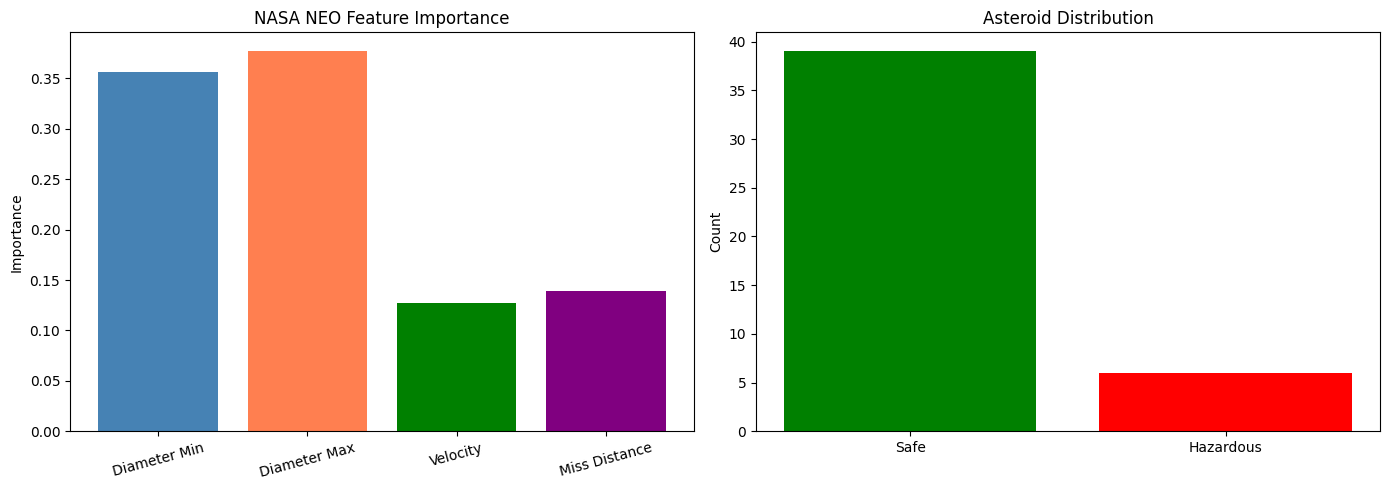

In [8]:
import matplotlib
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
feat_names = ["Diameter Min", "Diameter Max", "Velocity", "Miss Distance"]
axes[0].bar(feat_names, model.feature_importances_, color=["steelblue","coral","green","purple"])
axes[0].set_title("NASA NEO Feature Importance")
axes[0].set_ylabel("Importance")
axes[0].tick_params(axis="x", rotation=15)

# Hazardous vs Safe
axes[1].bar(["Safe", "Hazardous"], [(y==0).sum(), y.sum()], color=["green", "red"])
axes[1].set_title("Asteroid Distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("nasa_neo_analysis.png", dpi=100, bbox_inches="tight")
plt.show()


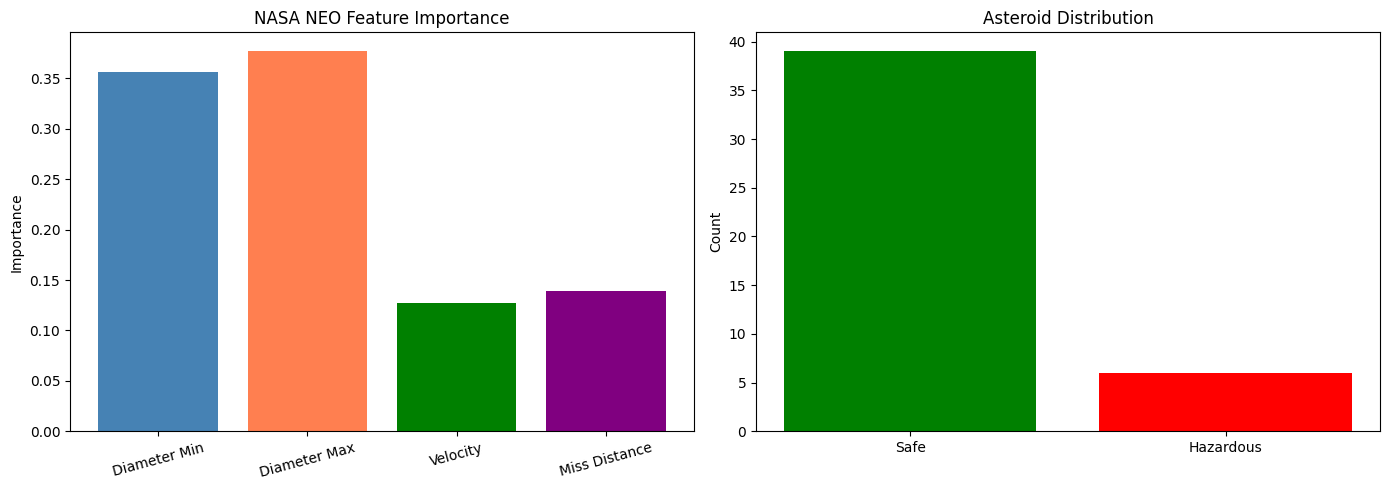

In [7]:
# Jupyter дотор график харуулах
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
feat_names = ["Diameter Min", "Diameter Max", "Velocity", "Miss Distance"]
axes[0].bar(feat_names, model.feature_importances_, 
            color=["steelblue","coral","green","purple"])
axes[0].set_title("NASA NEO Feature Importance")
axes[0].set_ylabel("Importance")
axes[0].tick_params(axis="x", rotation=15)

# Hazardous vs Safe
axes[1].bar(["Safe", "Hazardous"], [(y==0).sum(), y.sum()], 
            color=["green", "red"])
axes[1].set_title("Asteroid Distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()
